# SNR-threshold curves in $(m_1, z)$ for equal-mass binaries

This notebook plots the SNR threshold contour in the source-frame primary mass and redshift plane for:

- LISA, with merger time fixed to 4 yr before coalescence
- LGWA, using the full LGWA band
- LIGO, using the full ground-based band
- Cosmic Explorer (CE), using the full ground-based band

The binaries are equal-mass: `m2 = m1`. The threshold curve is the contour where `SNR = RHO_THR`.


In [12]:
from pathlib import Path
import importlib.util
import os

os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd().parent / '.matplotlib-cache' if Path.cwd().name == 'code' else Path.cwd() / '.matplotlib-cache'))

import numpy as np
import scipy.integrate
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['text.usetex'] = True

%config InlineBackend.figure_format = 'retina'
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

module_path = Path('test_notebook_functions.py')
if not module_path.exists():
    module_path = Path('code/test_notebook_functions.py')
spec = importlib.util.spec_from_file_location('tnf', module_path)
tnf = importlib.util.module_from_spec(spec)
spec.loader.exec_module(tnf)

CODE_DIR = module_path.resolve().parent
DATA_DIR = CODE_DIR.parent / 'data'

plt.rcParams.update({
    'figure.figsize': (8.0, 5.8),
    'font.size': 20,
    'axes.grid': True,
    'grid.linestyle': ':',
})


In [2]:
RHO_THR = 8.0
LISA_T_MERGER_YR = 4.0
LISA_T_OBS_YR = 4.0

M1_GRID = np.geomspace(5.0, 500.0, 100)
Z_GRID = np.geomspace(1.0e-3, 100.0, 100)

LGWA_F_MIN = 1.0e-3
LGWA_F_MAX = 3.0
LIGO_F_MIN = 5.0
N_FREQ = 1200


In [3]:
def load_lgwa_psd_from_code_dir(f):
    data = np.loadtxt(CODE_DIR / 'LGWA_Si_psd.txt')
    return np.interp(f, data[:, 0], data[:, 1])


tnf.lgwa_psd = load_lgwa_psd_from_code_dir


ligo_data = np.loadtxt(DATA_DIR / 'LIGO_O5_psd.txt')
ligo_freq = ligo_data[:, 0]
ligo_psd_values = ligo_data[:, 1]

ce_data = np.loadtxt(DATA_DIR / 'cosmic_explorer_strain.txt')
ce_freq = ce_data[:, 0]
ce_psd_values = ce_data[:, 1] ** 2


def ligo_psd(f):
    f = np.asarray(f, dtype=float)
    return np.interp(f, ligo_freq, ligo_psd_values, left=np.inf, right=np.inf)


def ce_psd(f):
    f = np.asarray(f, dtype=float)
    return np.interp(f, ce_freq, ce_psd_values, left=np.inf, right=np.inf)


def full_band_snr(m1, m2, z, f_min, f_max, psd_func, prefactor):
    dl_mpc = float(tnf.luminosity_distance_mpc_from_z(float(z)))
    dl_si = dl_mpc * 1.0e6 * tnf.pc
    transitions = tnf.phenoma_transition_frequencies(m1, m2, z)
    f_high = min(float(transitions['f3']), f_max)
    if not np.isfinite(f_high) or f_high <= f_min:
        return 0.0
    frequencies = np.geomspace(f_min, f_high, N_FREQ)
    h_tilde = tnf.phenoma_fourier_amplitude(frequencies, m1, m2, z, dl_si)
    psd = psd_func(frequencies)
    valid = np.isfinite(psd) & (psd > 0.0)
    if np.count_nonzero(valid) < 2:
        return 0.0
    integrand = h_tilde[valid] ** 2 / psd[valid]
    integral = scipy.integrate.trapezoid(integrand, frequencies[valid])
    return float(np.sqrt(max(prefactor * integral, 0.0)))


def space_snr_at_4yr(m1, m2, z, detector, LAMIGO=1e7):
    dl_mpc = float(tnf.luminosity_distance_mpc_from_z(float(z)))
    _, rho = tnf.snr_vs_merger_time(
        m1,
        m2,
        dl_mpc,
        np.array([LISA_T_MERGER_YR]),
        detector=detector,
        observation_years=LISA_T_OBS_YR,
        LAMIGO=LAMIGO
    )
    return float(rho[0])


def lisa_snr_at_4yr(m1, m2, z):
    return space_snr_at_4yr(m1, m2, z, 'LISA')


def taiji_snr_at_4yr(m1, m2, z):
    return space_snr_at_4yr(m1, m2, z, 'Taiji')


def tianqin_snr_at_4yr(m1, m2, z):
    return space_snr_at_4yr(m1, m2, z, 'TianQin')


def decigo_snr_at_4yr(m1, m2, z):
    return space_snr_at_4yr(m1, m2, z, 'DECIGO')


def amigo_snr_at_4yr(m1, m2, z, LAMIGO=1e7):
    return space_snr_at_4yr(m1, m2, z, 'AMIGO', LAMIGO=LAMIGO)
def amigo_5_snr_at_4yr(m1, m2, z, LAMIGO=5e7):
    return space_snr_at_4yr(m1, m2, z, 'AMIGO', LAMIGO=LAMIGO)


def lgwa_full_band_snr(m1, m2, z):
    return full_band_snr(m1, m2, z, LGWA_F_MIN, LGWA_F_MAX, tnf.lgwa_psd, prefactor=32.0 / 25.0)


def ligo_full_band_snr(m1, m2, z):
    transitions = tnf.phenoma_transition_frequencies(m1, m2, z)
    f_max = float(transitions['f3'])
    return full_band_snr(m1, m2, z, LIGO_F_MIN, f_max, ligo_psd, prefactor=32.0 / 25.0)


def ce_full_band_snr(m1, m2, z):
    transitions = tnf.phenoma_transition_frequencies(m1, m2, z)
    f_max = float(transitions['f3'])
    return full_band_snr(m1, m2, z, LIGO_F_MIN, f_max, ce_psd, prefactor=32.0 / 25.0)


In [6]:
def compute_snr_grid(snr_func, m1_grid=M1_GRID, z_grid=Z_GRID):
    grid = np.zeros((len(z_grid), len(m1_grid)))
    for iz, z in enumerate(z_grid):
        for im, m1 in enumerate(m1_grid):
            grid[iz, im] = snr_func(float(m1), float(m1), float(z))
    return grid


snr_grids = {
    r'LISA': compute_snr_grid(lisa_snr_at_4yr),
    r'Taiji': compute_snr_grid(taiji_snr_at_4yr),
    r'TianQin': compute_snr_grid(tianqin_snr_at_4yr),
    r'LGWA': compute_snr_grid(lgwa_full_band_snr),
    r'AMIGO': compute_snr_grid(amigo_snr_at_4yr),
    r'AMIGO-5': compute_snr_grid((amigo_5_snr_at_4yr)),
    'aLIGO O5': compute_snr_grid(ligo_full_band_snr),
    'CE': compute_snr_grid(ce_full_band_snr),
}

for name, grid in snr_grids.items():
    print(name, 'SNR range:', np.nanmin(grid), np.nanmax(grid))


LISA SNR range: 0.02664296141331616 15487.946404908289
Taiji SNR range: 0.04699195223345464 29227.850061726956
TianQin SNR range: 0.034310786784550164 9980.563194402248
LGWA SNR range: 0.051584819580170665 15012.248727332419
AMIGO SNR range: 0.05730612535586153 16677.237562458507
AMIGO-5 SNR range: 0.09786883944135857 28481.83000952477
aLIGO O5 SNR range: 0.0 32414.31947218482
CE SNR range: 0.0 1414842.9923577737


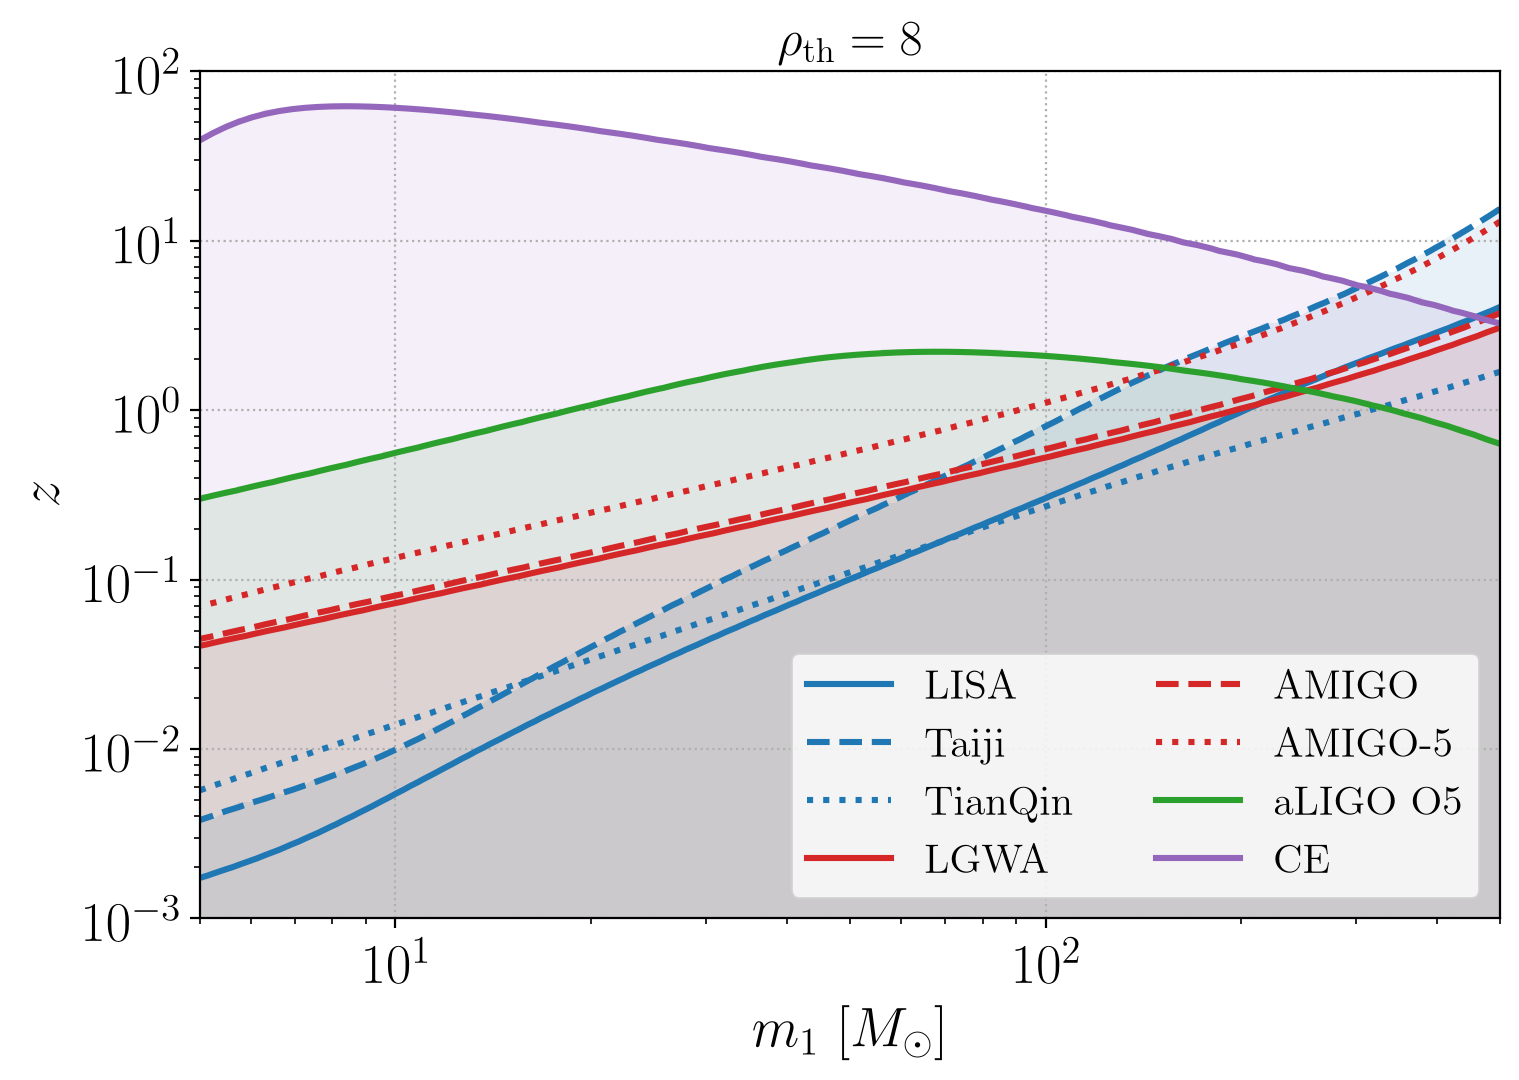

In [13]:
MESH_M1, MESH_Z = np.meshgrid(M1_GRID, Z_GRID)

fig, ax = plt.subplots()
colors = {
    r'LISA': '#1f77b4',
    r'Taiji': '#1f77b4',
    r'TianQin': '#1f77b4',
    r'LGWA': '#d62728',
    r'AMIGO': '#d62728',
    r'AMIGO-5': '#d62728',
    'aLIGO O5': '#2ca02c',
    'CE': '#9467bd',
}
linestyles = {
    r'LISA': '-',
    r'Taiji': '--',
    r'TianQin': ':',
    r'LGWA': '-',
    r'AMIGO': '--',
    r'AMIGO-5': ':',
    'aLIGO O5': '-',
    'CE': '-',
}
shade_alpha = {
    r'LISA': 0.0,
    r'Taiji': 0.10,
    r'TianQin': 0.0,
    r'LGWA': 0.1,
    r'AMIGO': 0.,
    r'AMIGO-5': 0.,
    'aLIGO O5': 0.1,
    'CE': 0.1,
}

legend_handles = []
for name, grid in snr_grids.items():
    detectable = grid >= RHO_THR
    if shade_alpha[name] > 0.0:
        ax.contourf(
            MESH_M1,
            MESH_Z,
            detectable.astype(float),
            levels=[0.5, 1.5],
            colors=[colors[name]],
            alpha=shade_alpha[name],
        )
    ax.contour(
        MESH_M1,
        MESH_Z,
        grid,
        levels=[RHO_THR],
        colors=[colors[name]],
        linestyles=[linestyles[name]],
        linewidths=2.2,
    )
    legend_handles.append(plt.Line2D([0], [0], color=colors[name], ls=linestyles[name], lw=2.2, label=name))

# ax.set_ylim(top=10)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$m_1$ [$M_\odot$]')
ax.set_ylabel('$z$')
ax.set_title(rf'$\rho_{{\rm th}}={RHO_THR:g}$', fontsize=18)
ax.legend(handles=legend_handles, loc='lower right', fontsize=15,ncol=2)
plt.tight_layout()
plt.savefig('../plots/snr_threshold_contours.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
M1_GRID = np.geomspace(5.0, 500.0, 100)
Z_GRID = np.geomspace(1.0e-2, 1000.0, 100)

def compute_snr_grid(snr_func, m1_grid=M1_GRID, z_grid=Z_GRID):
    grid = np.zeros((len(z_grid), len(m1_grid)))
    for iz, z in enumerate(z_grid):
        for im, m1 in enumerate(m1_grid):
            grid[iz, im] = snr_func(float(m1), float(m1), float(z))
    return grid


snr_grids = {
    r'DECIGO ($\tau_c=T_{\rm obs}$)': compute_snr_grid(decigo_snr_at_4yr),
}


In [ ]:
for name, grid in snr_grids.items():
    print(name, 'SNR range:', np.nanmin(grid), np.nanmax(grid))


DECIGO ($\tau_c=T_{\rm obs}$) SNR range: 6.976486665427933 322675.12126346177


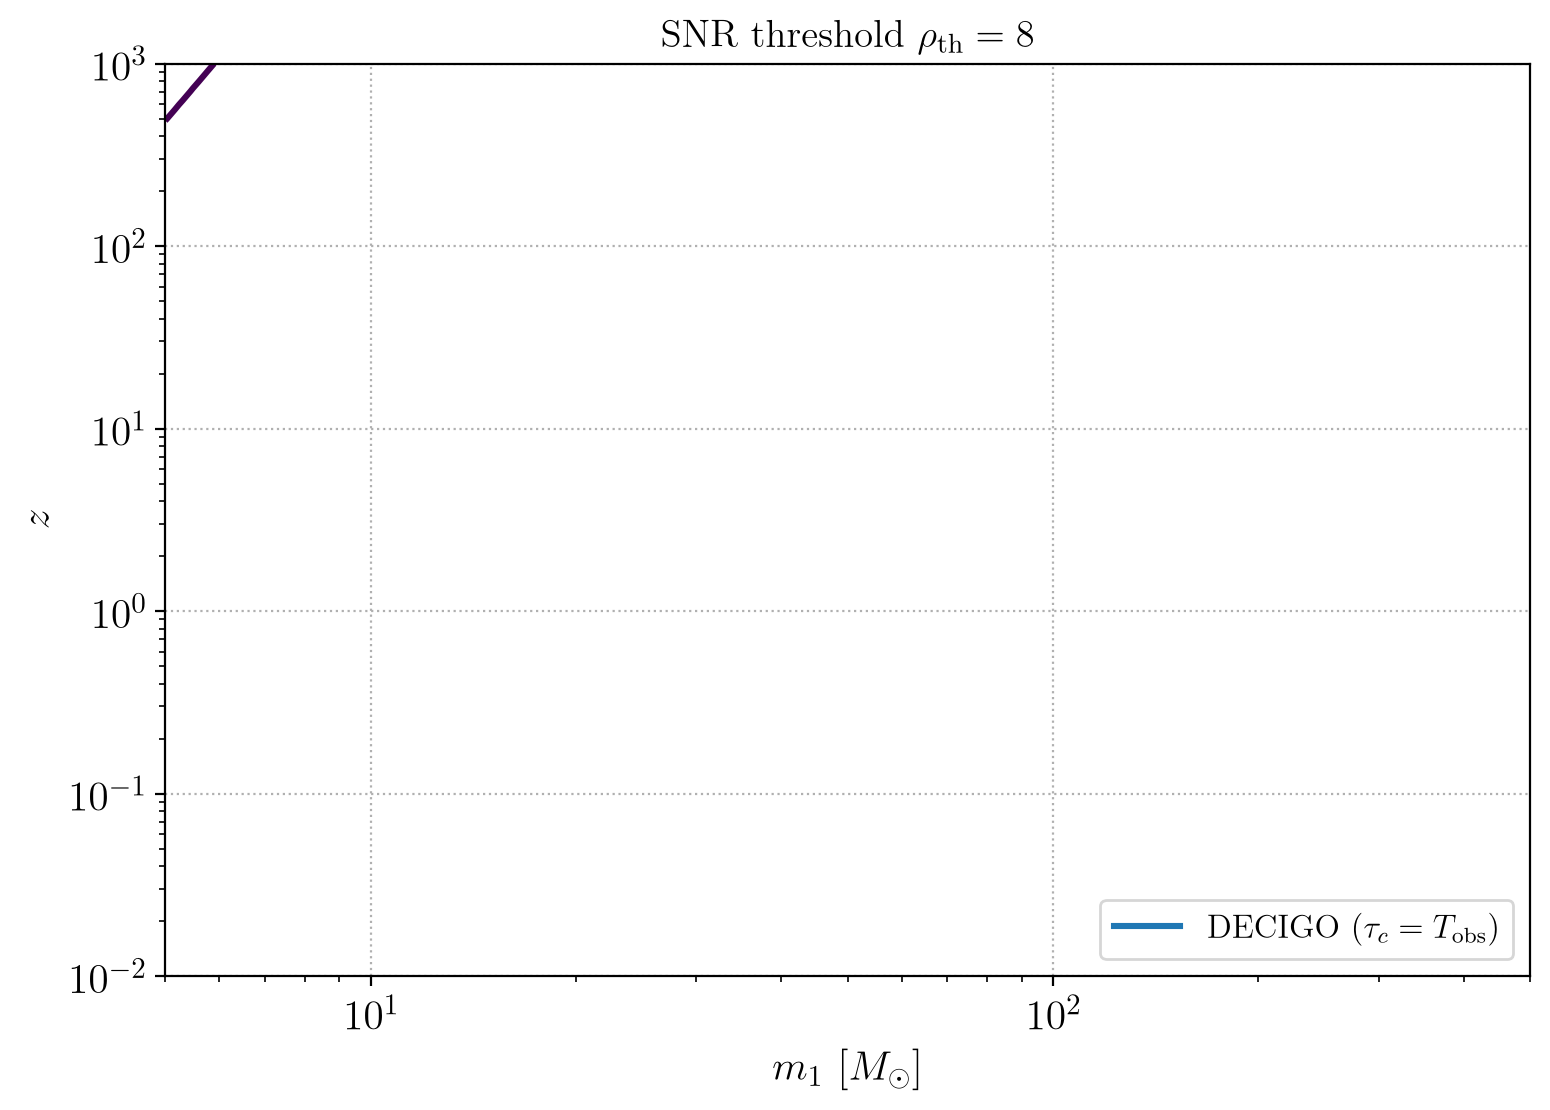

In [ ]:
M1_GRID = np.geomspace(5.0, 500.0, 100)
Z_GRID = np.geomspace(1.0e-2, 1000.0, 100)

MESH_M1, MESH_Z = np.meshgrid(M1_GRID, Z_GRID)

fig, ax = plt.subplots()
colors = {
    r'DECIGO ($\tau_c=T_{\rm obs}$)': '#1f77b4',
}

legend_handles = []
for name, grid in snr_grids.items():
    detectable = grid >= RHO_THR
    ax.contour(
        MESH_M1,
        MESH_Z,
        grid,
        levels=[RHO_THR],
        linewidths=2.2,
    )
    legend_handles.append(plt.Line2D([0], [0], lw=2.2, label=name))

# ax.set_ylim(top=10)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$m_1$ [$M_\odot$]')
ax.set_ylabel('$z$')
ax.set_title(rf'SNR threshold $\rho_{{\rm th}}={RHO_THR:g}$', fontsize=14)
ax.legend(handles=legend_handles, loc='lower right', fontsize=12)
plt.tight_layout()